In [4]:
import pandas as pd

df = pd.read_csv('/content/Cloud_SupplyChain_Dataset.csv')

df.head()

,timestamp,product_id,product_category,warehouse_location,inventory_level,units_sold,unit_price,lead_time_days,restock_quantity,promotion_flag,temperature_celsius,humidity_percent,truck_arrival_delay_mins,demand_forecast
0,2024-01-01,P003,Apparel,WH05,242,35,440.60,10,125,1,34.34,36.32,31,30
1,2024-01-02,P008,Home Goods,WH01,471,30,498.80,8,115,1,15.00,69.94,28,34
2,2024-01-03,P006,Apparel,WH02,122,26,454.84,4,294,0,21.57,65.91,96,30
3,2024-01-04,P002,FMCG,WH02,274,35,437.41,1,111,0,22.44,75.36,70,37
4,2024-01-05,P002,Home Goods,WH02,119,31,280.21,2,123,0,17.42,43.70,24,27


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [6]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 3204 non-null   object 
 1   product_id                3204 non-null   object 
 2   product_category          3204 non-null   object 
 3   warehouse_location        3204 non-null   object 
 4   inventory_level           3204 non-null   int64  
 5   units_sold                3204 non-null   int64  
 6   unit_price                3204 non-null   float64
 7   lead_time_days            3204 non-null   int64  
 8   restock_quantity          3204 non-null   int64  
 9   promotion_flag            3204 non-null   int64  
 10  temperature_celsius       3204 non-null   float64
 11  humidity_percent          3204 non-null   float64
 12  truck_arrival_delay_mins  3204 non-null   int64  
 13  demand_forecast           3204 non-null   int64  
dtypes: float

,0
timestamp,0
product_id,0
product_category,0
warehouse_location,0
inventory_level,0
units_sold,0
unit_price,0
lead_time_days,0
restock_quantity,0
promotion_flag,0


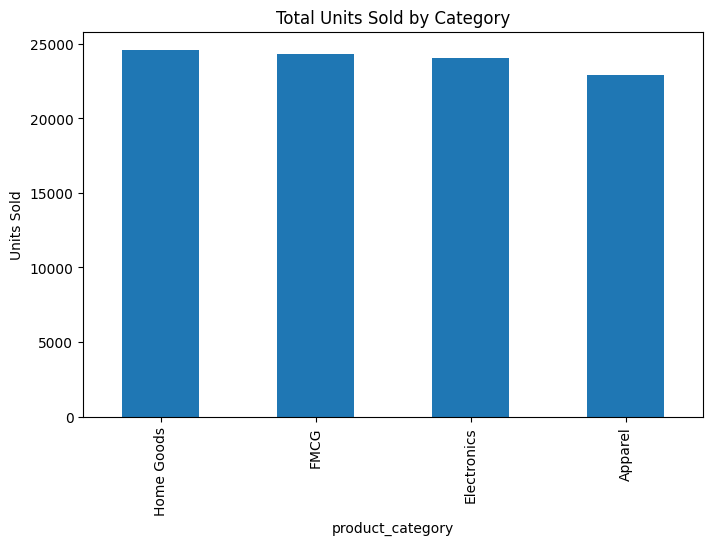

In [7]:
df.groupby('product_category')['units_sold'].sum().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Total Units Sold by Category')
plt.ylabel('Units Sold')
plt.show()

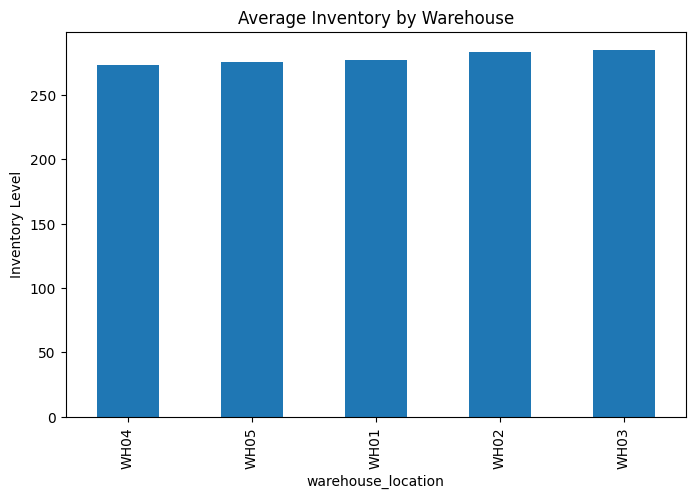

In [8]:
df.groupby('warehouse_location')['inventory_level'].mean().sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Inventory by Warehouse')
plt.ylabel('Inventory Level')
plt.show()

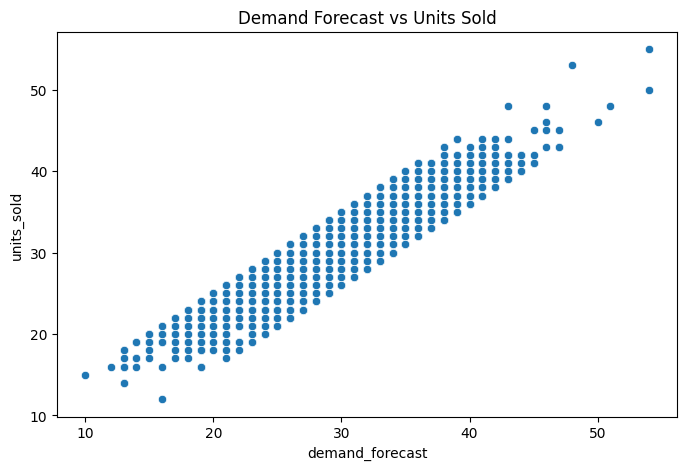

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='demand_forecast',
    y='units_sold',
    data=df
)

plt.title('Demand Forecast vs Units Sold')
plt.show()

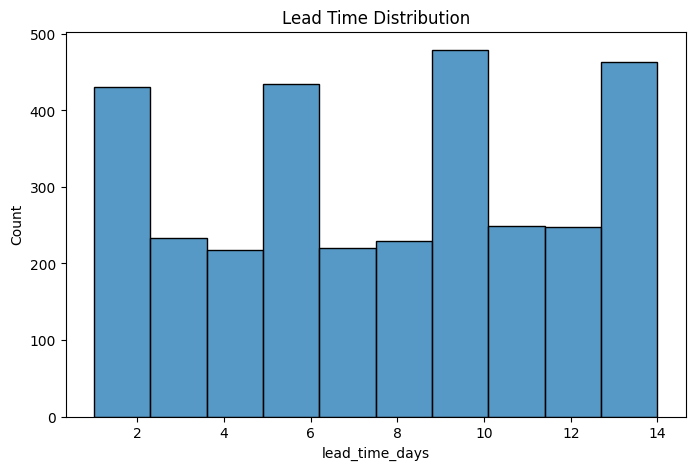

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['lead_time_days'], bins=10)

plt.title('Lead Time Distribution')
plt.show()

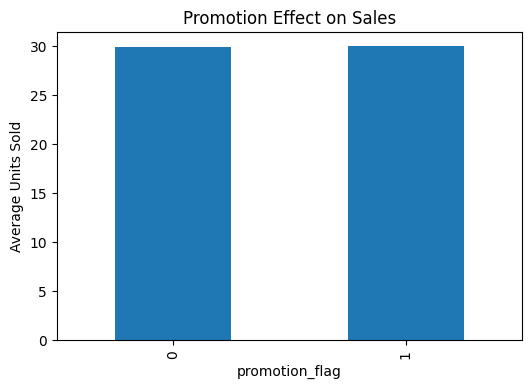

In [11]:
df.groupby('promotion_flag')['units_sold'].mean().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Promotion Effect on Sales')
plt.ylabel('Average Units Sold')
plt.show()

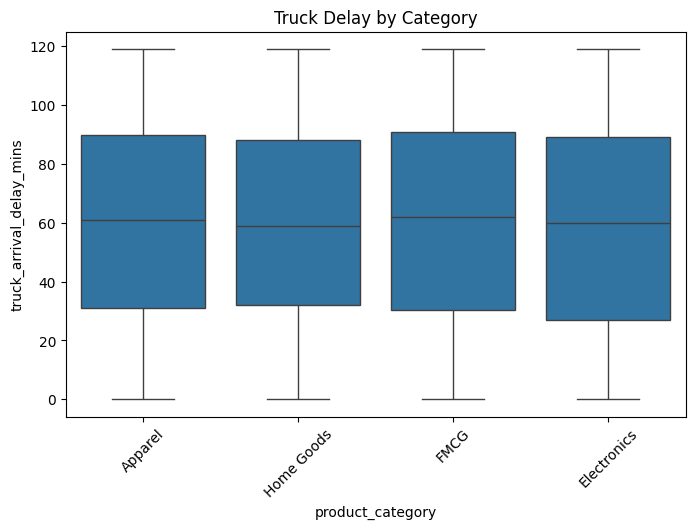

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='product_category',
    y='truck_arrival_delay_mins',
    data=df
)

plt.xticks(rotation=45)
plt.title('Truck Delay by Category')
plt.show()

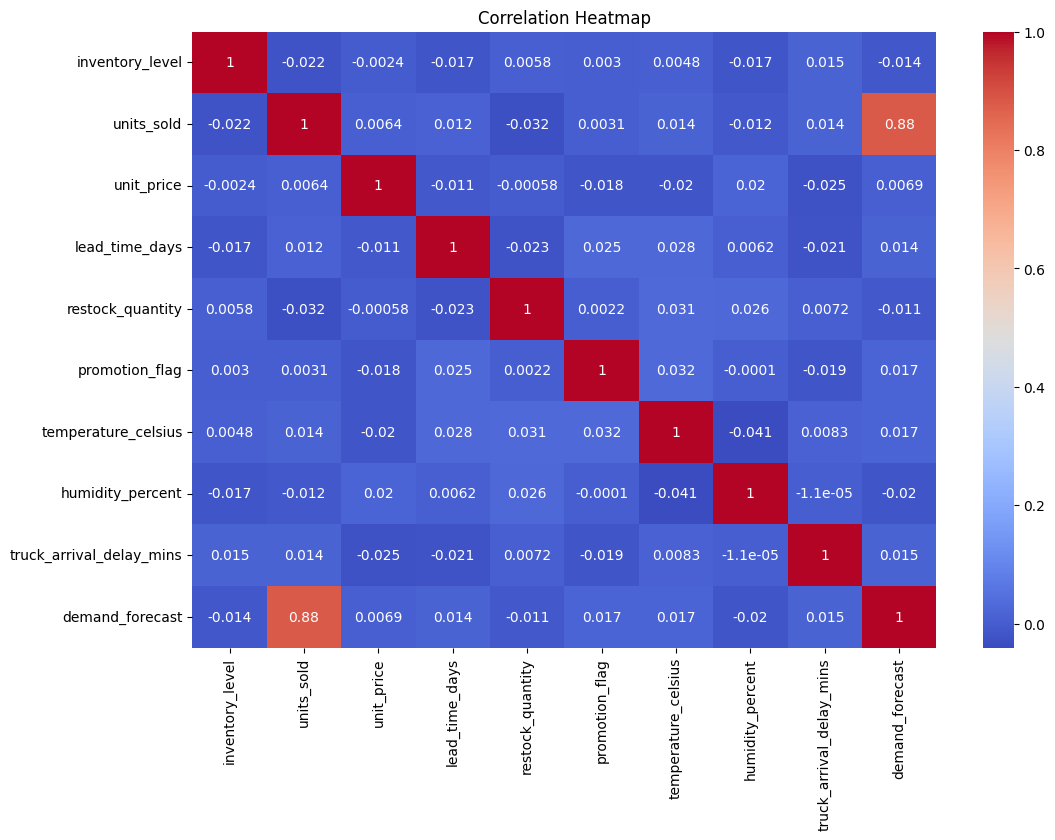

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

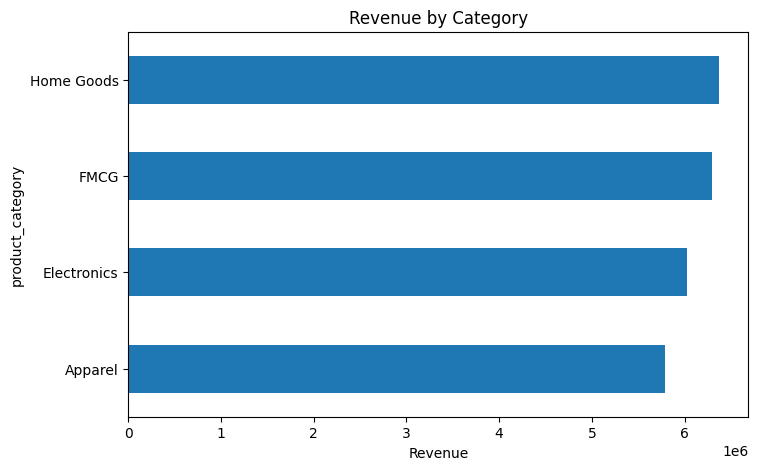

In [14]:
df['revenue'] = df['units_sold'] * df['unit_price']

df.groupby('product_category')['revenue'].sum().sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Revenue by Category')
plt.xlabel('Revenue')
plt.show()

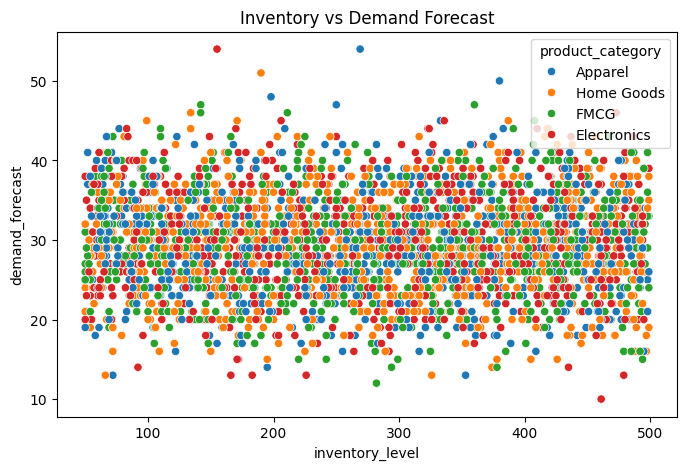

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='inventory_level',
    y='demand_forecast',
    hue='product_category',
    data=df
)

plt.title('Inventory vs Demand Forecast')
plt.show()

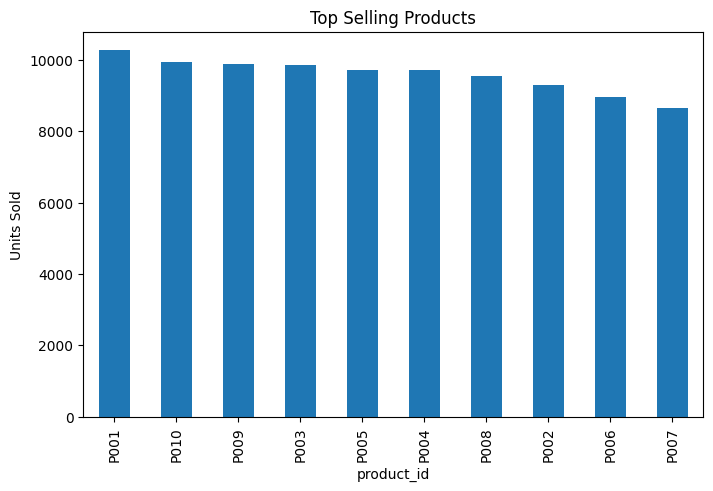

In [16]:
df.groupby('product_id')['units_sold'].sum().sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Top Selling Products')
plt.ylabel('Units Sold')
plt.show()